<a href="https://colab.research.google.com/github/JonathasHFerreira/Deteccao_de_fraudes_jonathas/blob/main/deteccao_fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1


In [2]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [5]:
print(os.listdir(path))

['PS_20174392719_1491204439457_log.csv']


In [8]:
nRowsRead = 1000

df1 = pd.read_csv(os.path.join(path, 'PS_20174392719_1491204439457_log.csv'), delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'PS_20174392719_1491204439457_log.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 11 columns


In [9]:
df1.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [15]:
df1.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1000.0,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.0
mean,1.0,1.181995e+05,8.646043e+05,8.849988e+05,6.657141e+05,1.224672e+06,0.009000,0.0
std,0.0,2.484799e+05,2.078040e+06,2.127790e+06,2.060515e+06,3.436780e+06,0.094488,0.0
min,1.0,8.730000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.0,4.474727e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,1.0,1.465808e+04,1.451800e+04,5.661830e+03,2.875506e+04,0.000000e+00,0.000000,0.0
75%,1.0,1.427203e+05,1.079092e+05,1.021042e+05,4.366312e+05,7.301112e+05,0.000000,0.0
max,1.0,2.545478e+06,9.716462e+06,9.987287e+06,1.766482e+07,1.916920e+07,1.000000,0.0


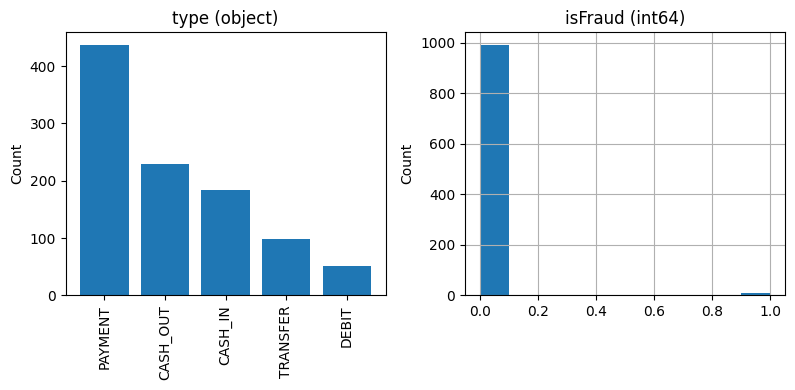

In [11]:
def plotPerColumnDistribution(df, nGraphPerRow, nPerGraph):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]].copy() # Reduce to columns with > 1 unique values and < 50 unique values
    nCol = df.shape[1]
    nRow = (nCol + nGraphPerRow - 1) // nGraphPerRow # Calculate number of rows for subplots
    plt.figure(figsize=(nGraphPerRow * 4, nRow * 4)) # Adjust figure size

    for i, col in enumerate(df.columns):
        plt.subplot(nRow, nGraphPerRow, i + 1)
        col_type = df[col].dtype
        if col_type == 'object' or col_type.name == 'category': # Categorical
            if nunique[col] > nPerGraph:
                # Plot top nPerGraph values
                temp_counts = df[col].value_counts().nlargest(nPerGraph)
                plt.bar(temp_counts.index, temp_counts.values)
                plt.xticks(rotation=90)
            else:
                # Plot all values
                temp_counts = df[col].value_counts()
                plt.bar(temp_counts.index, temp_counts.values)
                plt.xticks(rotation=90)
        else: # Numerical
            df[col].hist()
        plt.title(f'{col} ({col_type})')
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

plotPerColumnDistribution(df1, 10, 5)